In [380]:
# Import necessary libraries
import pandas as pd
import pickle
import matplotlib.pyplot as plt

# For machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [345]:
# Load the dataset
dataset = pd.read_csv("50_Startups.csv")

In [390]:
# Quick view of the data
print(dataset.head())
print(dataset.describe())
print(dataset.info())

   R&D Spend  Administration  Marketing Spend     Profit  State_Florida  \
0  165349.20       136897.80        471784.10  192261.83          False   
1  162597.70       151377.59        443898.53  191792.06          False   
2  153441.51       101145.55        407934.54  191050.39           True   
3  144372.41       118671.85        383199.62  182901.99          False   
4  142107.34        91391.77        366168.42  166187.94           True   

   State_New York  
0            True  
1           False  
2           False  
3            True  
4           False  
           R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000        50.000000      50.000000
mean    73721.615600   121344.639600    211025.097800  112012.639200
std     45902.256482    28017.802755    122290.310726   40306.180338
min         0.000000    51283.140000         0.000000   14681.400000
25%     39936.370000   103730.875000    129300.132500   90138.902500
50%     73051.0

In [346]:
# Handle categorical variable (State)
dataset = pd.get_dummies(dataset, drop_first = 1)

In [347]:
# Define features and target variable
x = dataset.drop("Profit", axis = 1)
y = dataset["Profit"]

In [348]:
# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

In [349]:
# Build and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [350]:
# Predict on test set
y_pred = model.predict(X_test)

In [351]:
# Get the weight values
weight = model.coef_
weight

array([ 8.04937292e-01, -9.12577104e-02,  2.80672826e-02,  4.58070775e+02,
       -1.23515673e+03])

In [352]:
# Get the bais value
bais = model.intercept_
bais

57412.64071380658

In [353]:
# Evaluate the model by result
r_result = r2_score(y_test, y_pred)
r_result

0.93971080633682

In [354]:
# Evaluate the Error
mse = mean_squared_error(y_test, y_pred)
mse

84826955.03358738

In [355]:
# Model coefficients
coefficients = pd.DataFrame(model.coef_, x.columns, columns = ["Coefficient"])
coefficients

,Coefficient
R&D Spend,0.804937
Administration,-0.091258
Marketing Spend,0.028067
State_Florida,458.070775
State_New York,-1235.156732


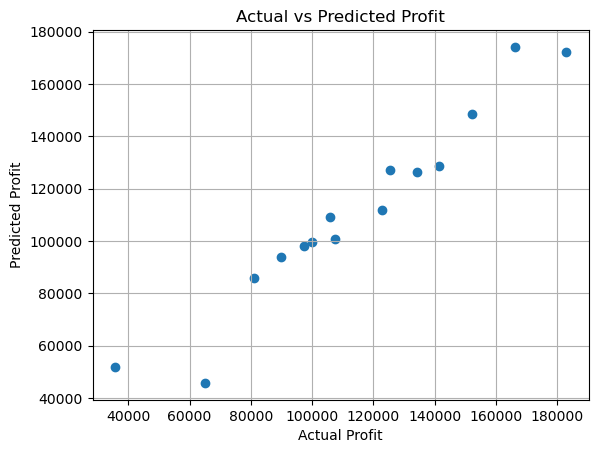

In [378]:
# Optional: Plotting actual vs predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.grid(1)
plt.show()

In [ ]:
# Save the the model
filename = "finalized_model_mul_linear.sav"
pickle.dump(model, open(filename, "wb"))